In [55]:
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms 

In [56]:
import gc

gc.collect()
torch.cuda.empty_cache()
print(torch.cuda.memory_allocated() / 1024**2, "MB")

729.8984375 MB


In [57]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vgg = models.vgg16(pretrained=True).features #берём без полносвязных слоёв
vgg = vgg.to(DEVICE)
vgg.eval()

for param in vgg.parameters():
    param.requires_grad = False

print(vgg)

c:\Users\semen\AppData\Local\pypoetry\Cache\virtualenvs\priceclassifier-0_d4FkaK-py3.13\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\semen\AppData\Local\pypoetry\Cache\virtualenvs\priceclassifier-0_d4FkaK-py3.13\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [58]:
def load_image(path, max_size = 512):
    image = Image.open(path).convert("RGB") #ТАК КАК ВГГ РАБОТАЕТ В РГБ

    transform = transforms.Compose([
        transforms.Resize(max_size),
        transforms.ToTensor()
    ])

    image = transform(image).unsqueeze(0) #dobav batch 

    return image.to(DEVICE)

content = load_image("style\main1.jpg")
style = load_image("style\style4.jpg")

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
C:\Users\semen\AppData\Local\Temp\ipykernel_23772\347612749.py:13: SyntaxWarning: invalid escape sequence '\m'
  content = load_image("style\main1.jpg")
C:\Users\semen\AppData\Local\Temp\ipykernel_23772\347612749.py:14: SyntaxWarning: invalid escape sequence '\s'
  style = load_image("style\style4.jpg")


In [59]:
def get_features(x, model):
    layers = {
        '0': 'conv1_1',
        '5': 'conv2_1',
        '10': 'conv3_1',
        '19': 'conv4_1',
        '28': 'conv5_1'
    }

    features = {}
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
    
    return features

In [60]:
content_features = get_features(content, vgg)
style_features = get_features(style, vgg)

In [61]:
def gram_matrix(tensor):
    _, c, h, w = tensor.size()
    tensor = tensor.view(c, h*w)
    gram = torch.mm(tensor, tensor.t())

    return gram

In [62]:
style_grams = {layer: gram_matrix(style_features[layer])
               for layer in style_features}

In [63]:
def compute_rbf_kernel_channels(f1, f2, sigma=1.0):
    """
    f1: [Channels, H*W]
    f2: [Channels, H*W]
    Результат: матрица [Channels, Channels]
    """
    # Теперь x и y имеют размер [Channels, H*W]
    # Мы считаем сходство между КАНАЛАМИ
    x = f1 
    y = f2
    
    # x_norm: [Channels, 1]
    x_norm = x.pow(2).sum(1).view(-1, 1)
    y_norm = y.pow(2).sum(1).view(1, -1)
    
    # dist: [Channels, Channels] - это ОЧЕНЬ мало и быстро
    dist = x_norm + y_norm - 2.0 * torch.mm(x, y.t())
    
    gamma = 1.0 / (2.0 * sigma**2)
    return torch.exp(-gamma * dist)

In [64]:
import torch.nn.functional as F

def kernel_style_loss(gen_f, style_f, sigma=1.0):
    # gen_f: [1, C, H1, W1]
    # style_f: [1, C, H2, W2]
    
    # 1. Приводим оба тензора к одинаковому пространственному размеру
    # Например, 128x128 или меньше. Это позволит сравнивать каналы.
    common_size = (128, 128) 
    gen_f_resized = F.adaptive_avg_pool2d(gen_f, common_size)
    style_f_resized = F.adaptive_avg_pool2d(style_f, common_size)
    
    c = gen_f.shape[1]
    
    # 2. Выпрямляем в [Channels, Pixels]
    # Теперь количество пикселей у обоих равно 128*128
    f_gen = gen_f_resized.view(c, -1)
    f_style = style_f_resized.view(c, -1)
    
    # 3. Считаем ядра (теперь размеры совпадут: [64, 16384])
    k_gen_gen = compute_rbf_kernel_channels(f_gen, f_gen, sigma)
    k_style_style = compute_rbf_kernel_channels(f_style, f_style, sigma)
    k_gen_style = compute_rbf_kernel_channels(f_gen, f_style, sigma)
    
    # MMD расстояние
    loss = k_gen_gen.mean() + k_style_style.mean() - 2 * k_gen_style.mean()
    return loss

def compute_rbf_kernel_channels(x, y, sigma=1.0):
    # x: [C, N], y: [C, N]
    x_norm = x.pow(2).sum(1).view(-1, 1) # [C, 1]
    y_norm = y.pow(2).sum(1).view(1, -1) # [1, C]
    
    # Теперь mm(x, y.t()) даст [C, C]
    dist = x_norm + y_norm - 2.0 * torch.mm(x, y.t())
    
    gamma = 1.0 / (2.0 * sigma**2)
    return torch.exp(-gamma * dist)

In [65]:
target = content.clone().requires_grad_(True).to(DEVICE)
optimizer = torch.optim.AdamW([target], lr = 0.005)

content_weight = 1e2
style_weight = 1e6
epoch = 300

In [66]:
style_weights = {
    'conv1_1': 0.3,
    'conv2_1': 0.5,
    'conv3_1': 0.5,
    'conv4_1': 2.0,
    'conv5_1': 3.0
}

In [67]:
total_loss = 0
layer_loss = 0 
content_loss = 0
content_features = get_features(content, vgg)
style_features = get_features(style, vgg)

for i in range(epoch):
    #torch.cuda.empty_cache()
    style_loss = 0
    target_features = get_features(target, vgg)

    content_loss = torch.mean( target_features['conv4_1'] - content_features['conv4_1'])**2

    for layer in style_features:
        gen_f = target_features[layer]    # Это и есть features_gen
        style_f = style_features[layer]  # Это и есть features_style
        
        # Вызываем функцию ядерного лосса для конкретного слоя
        # Мы передаем признаки ОДНОГО слоя за раз
        layer_kernel_loss = kernel_style_loss(gen_f, style_f, sigma=1.0)
        
        # Суммируем с весом слоя (который может подобрать ваша MLP)
        style_loss += style_weights[layer] * layer_kernel_loss
        
    
    total_loss = content_weight * content_loss + style_weight * style_loss 

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    print(f"Step {i}, Loss: {total_loss.item()}")

Step 0, Loss: 197828.375
Step 1, Loss: 140864.90625
Step 2, Loss: 101171.953125
Step 3, Loss: 73633.265625
Step 4, Loss: 53276.23046875
Step 5, Loss: 40447.4765625
Step 6, Loss: 38017.91015625
Step 7, Loss: 41359.47265625
Step 8, Loss: 37917.69140625
Step 9, Loss: 38391.58203125
Step 10, Loss: 45126.7890625
Step 11, Loss: 38219.67578125
Step 12, Loss: 38722.31640625
Step 13, Loss: 38505.59375
Step 14, Loss: 37777.58984375
Step 15, Loss: 37757.15234375
Step 16, Loss: 37764.9765625
Step 17, Loss: 38456.3203125
Step 18, Loss: 38183.3046875
Step 19, Loss: 37985.58984375
Step 20, Loss: 37725.0078125
Step 21, Loss: 37690.53515625
Step 22, Loss: 37799.89453125
Step 23, Loss: 37847.18359375
Step 24, Loss: 37658.41015625
Step 25, Loss: 37646.328125
Step 26, Loss: 37632.4140625
Step 27, Loss: 37600.34375
Step 28, Loss: 37576.5703125
Step 29, Loss: 37578.66796875
Step 30, Loss: 37606.1484375
Step 31, Loss: 37606.80078125
Step 32, Loss: 37554.11328125
Step 33, Loss: 37539.54296875
Step 34, Loss: 3

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.14062813..1.319263].


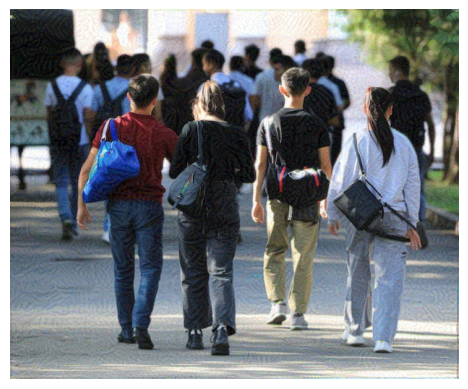

In [68]:
def imshow(tensor):
    image = tensor.clone().detach().cpu().squeeze(0)
    image = image.permute(1, 2, 0)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

imshow(target)